# Phase 4 — Machine Learning

Notebook pour exécuter la Phase 4 : 4.1 Segmentation (RFM), 4.2 Classification (churn) et 4.3 Régression (delivery_days).
Exécutez les cellules séquentiellement. Les artefacts sont sauvegardés dans `data/processed/` et `models/`.

In [ ]:
# Imports des librairies nécessaires
import os
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imports des modules Scikit-learn pour le clustering, la classification et la régression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor, AdaBoostClassifier
from sklearn.metrics import (
    classification_report, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, silhouette_score, r2_score,
    mean_squared_error, mean_absolute_error
)

# Définition d'une seed aléatoire pour la reproductibilité
RANDOM_STATE = 42

# Fonction pour trouver le répertoire racine du projet
def find_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'data').exists() and (candidate / 'db').exists():
            return candidate
    return cwd

# Définition des chemins vers les répertoires importants
ROOT = find_root()
PROCESSED = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
PLOTS = MODELS / 'plots'

# Création des répertoires s'ils n'existent pas
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)
os.makedirs(PLOTS, exist_ok=True)

# Affichage des chemins pour vérification
print('Project root:', ROOT)
print('Processed dir:', PROCESSED)
print('Models dir:', MODELS)

Project root: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI
Processed dir: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\data\processed
Models dir: E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\models


In [2]:
# Définition des chemins des fichiers de données préparés
orders_fp = PROCESSED / 'orders_features.csv'
rfm_fp = PROCESSED / 'rfm_matrix.csv'
rfm_std_fp = PROCESSED / 'rfm_standardized.csv'

# Assertion pour vérifier l'existence des fichiers essentiels
assert orders_fp.exists(), f"Fichier introuvable: {orders_fp}"
assert rfm_fp.exists(), f"Fichier introuvable: {rfm_fp}"

# Chargement des fichiers CSV dans des DataFrames Pandas
orders = pd.read_csv(orders_fp)
rfm = pd.read_csv(rfm_fp)
# Chargement de rfm_standardized si le fichier existe, sinon None
rfm_std = pd.read_csv(rfm_std_fp) if rfm_std_fp.exists() else None

# Affichage des dimensions (formes) des DataFrames chargés
print('orders shape:', orders.shape)
print('rfm shape:', rfm.shape)
if rfm_std is not None:
    print('rfm_standardized shape:', rfm_std.shape)

orders shape: (99441, 24)
rfm shape: (96096, 4)
rfm_standardized shape: (96096, 3)


### Préparation des données RFM

In [3]:
# Sélection des colonnes 'recency', 'frequency', 'monetary' pour le modèle RFM
rfm_model = rfm[['recency', 'frequency', 'monetary']].copy()

# Application d'une transformation logarithmique (log1p) aux colonnes 'frequency' et 'monetary'
# pour réduire l'asymétrie et gérer les valeurs nulles/zéros.
rfm_model['frequency'] = np.log1p(rfm_model['frequency'])
rfm_model['monetary'] = np.log1p(rfm_model['monetary'])

# Initialisation du Standard Scaler pour la standardisation des données
scaler = StandardScaler()
# Application du scaler pour transformer les données RFM (mise à l'échelle)
X = scaler.fit_transform(rfm_model)

# Affichage des dimensions des données transformées
print("Dimensions :", X.shape)

Dimensions : (96096, 3)


### Choisir le meilleur k (Elbow + Silhouette)

In [4]:
# Définition de la plage de valeurs pour k (nombre de clusters) à tester
ks = range(2, 9)

# Listes pour stocker les inerties et les scores de silhouette pour chaque k
inertias = []
silhouettes = []

# Boucle pour entraîner KMeans pour chaque valeur de k
for k in ks:
    # Initialisation du modèle KMeans
    model = KMeans(
        n_clusters=k, # Nombre de clusters
        random_state=RANDOM_STATE, # Graine aléatoire pour reproductibilité
        n_init=10 # Nombre d'initialisations différentes
    )

    # Entraînement du modèle et prédiction des labels de cluster
    labels = model.fit_predict(X)

    # Ajout de l'inertie du modèle à la liste
    inertias.append(model.inertia_)
    # Calcul et ajout du score de silhouette à la liste
    silhouettes.append(
        silhouette_score(X, labels)
    )

# Détermination du meilleur k basé sur le score de silhouette maximal
best_k = list(ks)[np.argmax(silhouettes)]

# Affichage du meilleur k et de son score de silhouette associé
print("Meilleur k :", best_k)
print("Silhouette :", max(silhouettes))

Meilleur k : 2
Silhouette : 0.7035084820848586


### Graphiques Elbow + Silhouette

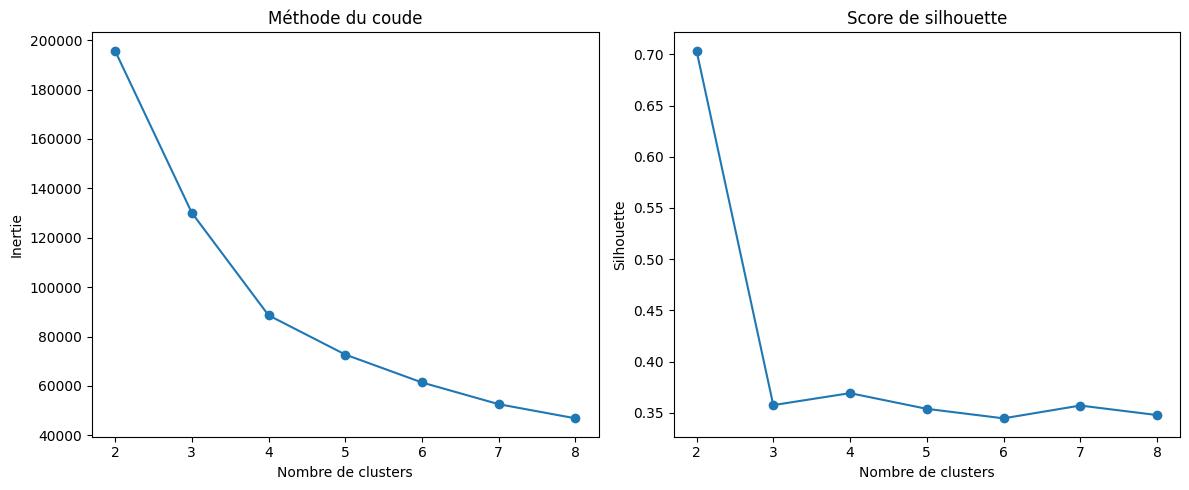

In [5]:
# Création d'une figure avec deux sous-graphiques pour visualiser les résultats
plt.figure(figsize=(12,5))

# Premier sous-graphique : Méthode du coude (Elbow Method)
plt.subplot(1,2,1) # 1 ligne, 2 colonnes, premier plot
plt.plot(ks, inertias, '-o') # Tracé des inerties en fonction de k
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")

# Deuxième sous-graphique : Score de silhouette
plt.subplot(1,2,2) # 1 ligne, 2 colonnes, deuxième plot
plt.plot(ks, silhouettes, '-o') # Tracé des scores de silhouette en fonction de k
plt.title("Score de silhouette")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette")
plt.tight_layout() # Ajuste automatiquement les paramètres du subplot pour un ajustement serré

# Sauvegarde du graphique combiné dans le répertoire PLOTS
plt.savefig(PLOTS / "rfm_elbow_silhouette.png")

# Affichage du graphique
plt.show()

### Entraîner KMeans

In [6]:
# Utilisation de la valeur de k déterminée comme le meilleur k
chosen_k = best_k

# Initialisation du modèle KMeans avec le nombre de clusters choisi
kmeans = KMeans(
    n_clusters=chosen_k, # Nombre de clusters
    random_state=RANDOM_STATE, # Graine aléatoire pour reproductibilité
    n_init=10 # Nombre d'initialisations différentes pour éviter les optima locaux
)

# Entraînement du modèle KMeans sur les données standardisées et prédiction des labels
labels_k = kmeans.fit_predict(X)

# Création d'une copie du DataFrame rfm original pour ajouter les clusters
rfm_out = rfm.copy()

# Ajout des labels de cluster KMeans au DataFrame rfm_out
rfm_out["kmeans_cluster"] = labels_k

# Calcul et affichage du score de silhouette final pour l'évaluation du clustering
print("Silhouette finale :",
      silhouette_score(X, labels_k))

Silhouette finale : 0.7035084820848586


Centres des clusters

In [7]:
# Inverse la transformation des centres de cluster pour les ramener à l'échelle d'origine
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

# Crée un DataFrame Pandas à partir des centres transformés, avec des noms de colonnes descriptifs
centers = pd.DataFrame(
    centers,
    columns=[
        "recency",
        "frequency (log)", # Indique que la fréquence était log-transformée
        "monetary (log)" # Indique que la monétaire était log-transformée
    ]
)

print("Centres des clusters")

# Affiche les centres des clusters
display(centers)

Centres des clusters


,recency,frequency (log),monetary (log)
0,288.364354,0.693147,4.709293
1,268.206874,1.128740,5.471572


Taille des clusters

In [8]:
# Calcule la taille de chaque cluster KMeans
# value_counts() compte le nombre d'occurrences de chaque label de cluster
# sort_index() trie les résultats par l'index (le numéro du cluster)
cluster_size = (
    rfm_out["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

# Affiche la taille de chaque cluster
print(cluster_size)

kmeans_cluster
0    93099
1     2997
Name: count, dtype: int64


Visualisation PCA

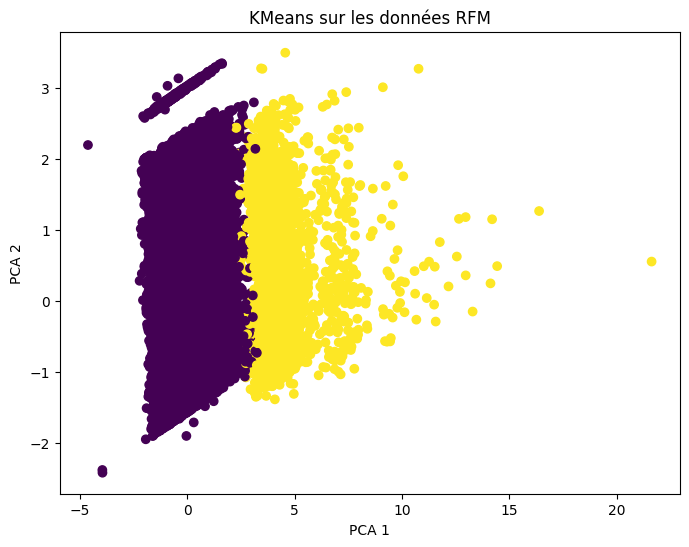

In [9]:
# Initialisation de l'Analyse en Composantes Principales (PCA) pour réduire la dimensionnalité à 2 composants
pca = PCA(n_components=2)

# Application de la PCA sur les données standardisées (X) pour obtenir des données en 2D
X_pca = pca.fit_transform(X)

# Création d'une figure pour le graphique
plt.figure(figsize=(8,6))

# Tracé des points PCA en utilisant les labels KMeans pour la couleur
plt.scatter(
    X_pca[:,0], # Première composante principale
    X_pca[:,1], # Deuxième composante principale
    c=labels_k # Couleur des points basée sur les clusters KMeans
)

# Ajout du titre et des étiquettes des axes
plt.title("KMeans sur les données RFM")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Affichage du graphique
plt.show()

Choisir eps avec la courbe k-distance

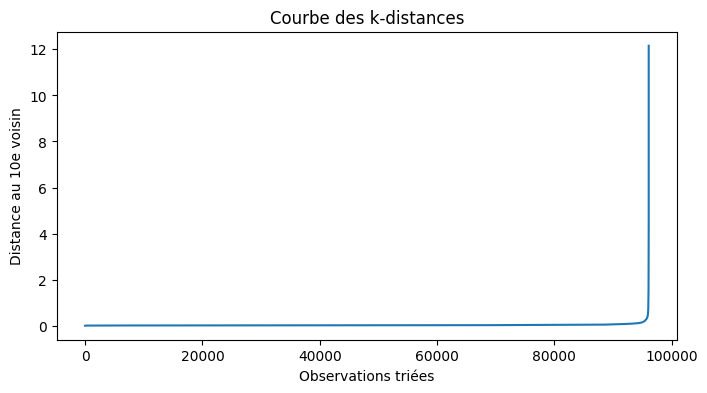

In [10]:
# Initialisation de NearestNeighbors pour trouver les 10 plus proches voisins de chaque point
neighbors = NearestNeighbors(
    n_neighbors=10 # Nombre de voisins à considérer
)

# Entraînement du modèle NearestNeighbors sur les données standardisées
neighbors.fit(X)

# Calcul des distances et des indices des 10 plus proches voisins
distances, indices = neighbors.kneighbors(X)

# Tri des distances au 10ème voisin pour chaque point
distances = np.sort(distances[:,9]) # La 10ème colonne correspond à la distance au 10ème voisin (index 9)

# Création d'une figure pour le graphique
plt.figure(figsize=(8,4))
# Tracé de la courbe des k-distances
plt.plot(distances)
# Ajout du titre et des étiquettes des axes
plt.title("Courbe des k-distances")
plt.xlabel("Observations triées")
plt.ylabel("Distance au 10e voisin")
# Affichage du graphique
plt.show()

### DBSCAN

In [11]:
# Définition du paramètre eps (rayon de recherche) pour DBSCAN
eps = 0.5 # Cette valeur est généralement choisie après l'analyse de la courbe k-distance

# Initialisation du modèle DBSCAN
dbscan = DBSCAN(
    eps=eps, # Rayon de recherche
    min_samples=10 # Nombre minimum de points pour former un cluster
)

# Entraînement du modèle DBSCAN sur les données standardisées et prédiction des labels
labels_db = dbscan.fit_predict(X)

# Ajout des labels de cluster DBSCAN au DataFrame rfm_out
rfm_out["dbscan_cluster"] = labels_db

# Affichage du nombre de points dans chaque cluster DBSCAN
# Les points étiquetés -1 sont considérés comme du bruit (outliers)
print(
    rfm_out["dbscan_cluster"]
    .value_counts()
    .sort_index()
)

dbscan_cluster
-1       94
 0    92779
 1     2731
 2      312
 3      180
Name: count, dtype: int64


Clients atypiques

In [12]:
# Calcule le nombre de points identifiés comme du bruit par DBSCAN (labels == -1)
noise = np.sum(labels_db == -1)

# Affiche le nombre de clients atypiques (bruit)
print("Clients atypiques :", noise)

Clients atypiques : 94


PCA de DBSCAN

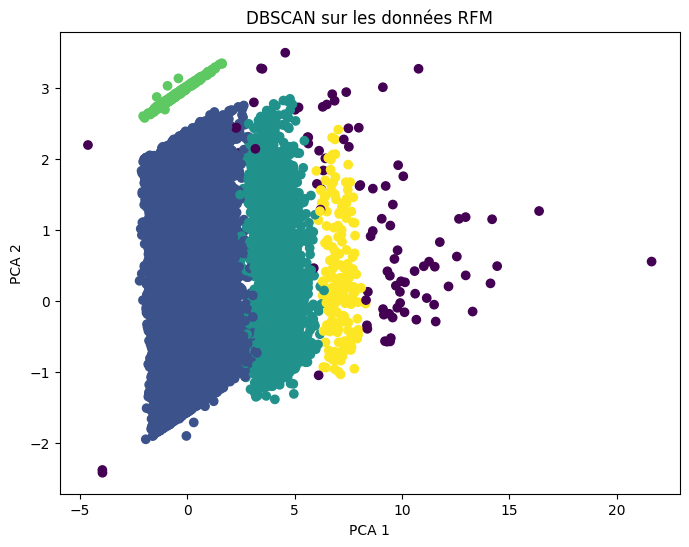

In [13]:
# Création d'une figure pour le graphique
plt.figure(figsize=(8,6))

# Tracé des points PCA en utilisant les labels DBSCAN pour la couleur
# Les points de bruit (labels -1) auront une couleur distincte
plt.scatter(
    X_pca[:,0], # Première composante principale
    X_pca[:,1], # Deuxième composante principale
    c=labels_db # Couleur des points basée sur les clusters DBSCAN
)

# Ajout du titre et des étiquettes des axes
plt.title("DBSCAN sur les données RFM")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

# Affichage du graphique
plt.show()

Sauvegarde

In [14]:
# Sauvegarde du DataFrame rfm_out (avec les clusters KMeans et DBSCAN) au format CSV
# Le fichier est enregistré dans le répertoire 'PROCESSED'
rfm_out.to_csv(
    PROCESSED / "rfm_segments.csv",
    index=False # Ne pas inclure l'index du DataFrame dans le fichier CSV
)

# Sauvegarde du modèle KMeans entraîné au format joblib
# Le modèle est enregistré dans le répertoire 'MODELS'
joblib.dump(
    kmeans,
    MODELS / "kmeans_rfm.joblib"
)

# Messages de confirmation de sauvegarde
print("Fichier rfm_segments.csv sauvegardé")
print("Modèle KMeans sauvegardé")

Fichier rfm_segments.csv sauvegardé
Modèle KMeans sauvegardé


## 4.2 Classification (churn)

Ce bloc prépare le jeu de données de classification `bad_review` avec les variables prescrites par le guide.

In [15]:
# Copie du DataFrame 'orders' pour la classification
df = orders.copy()
# Définition de la colonne cible pour la classification
target = 'bad_review'

# Suppression des lignes où la colonne cible est manquante
df = df[df[target].notna()]
# Conversion de la colonne cible en type entier (0 ou 1)
df[target] = df[target].astype(int)

# Définition des colonnes de caractéristiques à utiliser pour le modèle
feature_cols = [
    'total_price', 'total_freight', 'total_weight', 'n_items',
    'max_installments', 'payment_value', 'delivery_days', 'delay_days',
    'purchase_month', 'purchase_dow', 'main_category', 'payment_type',
    'customer_state'
]
# Vérification que toutes les colonnes de caractéristiques attendues sont présentes
missing = [c for c in feature_cols if c not in df.columns]
assert not missing, f"Missing expected feature columns: {missing}"

# Séparation des caractéristiques (X_cls) et de la cible (y_cls)
X_cls = df[feature_cols].copy()
y_cls = df[target]

# Division des données en ensembles d'entraînement, de validation et de test
# X_trainval contient les données d'entraînement et de validation, X_test pour le test final
X_trainval, X_test, y_trainval, y_test = train_test_split(X_cls, y_cls, test_size=0.2, stratify=y_cls, random_state=RANDOM_STATE)
# Division de X_trainval en ensembles d'entraînement (X_train) et de validation (X_val)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE)

# Identification des colonnes numériques et catégorielles
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object','category','bool']).columns.tolist()

# Pipeline de transformation pour les colonnes numériques (imputation des médianes et standardisation)
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
# Pipeline de transformation pour les colonnes catégorielles (imputation des valeurs les plus fréquentes et encodage One-Hot)
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # handle_unknown='ignore' gère les catégories inconnues lors de la transformation
])

# Combinateur de préprocesseurs pour appliquer différentes transformations à différents types de colonnes
preprocessor_cls = ColumnTransformer([('num', numeric_transformer, numeric_cols), ('cat', categorical_transformer, categorical_cols)], remainder='drop')

# Dictionnaire pour stocker les résultats de classification de chaque modèle
classification_results = {}

# Affichage des tailles des jeux de données préparés
print('Classification dataset prepared with', len(X_train), 'training rows and', len(X_test), 'test rows.')

Classification dataset prepared with 59203 training rows and 19735 test rows.


In [16]:
# Importe la fonction resample de sklearn.utils pour l'échantillonnage
from sklearn.utils import resample

# Crée une copie de l'ensemble d'entraînement et y ajoute la colonne cible
train = X_train.copy(); train['target'] = y_train.values

# Sépare la classe minoritaire (target=1) et la classe majoritaire (target=0)
minor = train[train['target']==1]
maj = train[train['target']==0]

# Suréchantillonne (oversample) la classe minoritaire pour qu'elle ait la même taille que la classe majoritaire
minor_up = resample(minor, replace=True, n_samples=len(maj), random_state=RANDOM_STATE)

# Concatène la classe majoritaire et la classe minoritaire suréchantillonnée, puis mélange l'ensemble
train_bal = pd.concat([maj, minor_up]).sample(frac=1, random_state=RANDOM_STATE)

# Sépare à nouveau les caractéristiques et la cible de l'ensemble d'entraînement équilibré
X_train_bal = train_bal.drop(columns=['target'])
y_train_bal = train_bal['target']

# Affiche un message de confirmation
print("# Oversample training set READY!")

# Oversample training set READY!


In [17]:
# Pipeline pour la régression logistique : préprocesseur + classifieur LogisticRegression
logistic_pipe = Pipeline([
    ('pre', preprocessor_cls), # Applique les transformations de pré-traitement
    ('clf', LogisticRegression(
        max_iter=1000, # Augmente le nombre maximum d'itérations pour la convergence
        class_weight='balanced', # Gère le déséquilibre des classes en ajustant les poids
        random_state=RANDOM_STATE # Graine aléatoire pour la reproductibilité
    ))
])

# Entraînement du pipeline sur l'ensemble d'entraînement suréchantillonné
logistic_pipe.fit(X_train_bal, y_train_bal)

# Prédictions sur les ensembles de validation et de test
y_val_pred = logistic_pipe.predict(X_val)
y_test_pred = logistic_pipe.predict(X_test)

# Prédictions des probabilités (si disponibles) pour le calcul de l'AUC-ROC
y_val_proba = logistic_pipe.predict_proba(X_val)[:,1] if hasattr(logistic_pipe, 'predict_proba') else (logistic_pipe.decision_function(X_val) if hasattr(logistic_pipe, 'decision_function') else None)
y_test_proba = logistic_pipe.predict_proba(X_test)[:,1] if hasattr(logistic_pipe, 'predict_proba') else (logistic_pipe.decision_function(X_test) if hasattr(logistic_pipe, 'decision_function') else None)

# Calcul des métriques d'évaluation pour l'ensemble de validation
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc = roc_auc_score(y_val, y_val_proba) if (y_val_proba is not None and len(set(y_val))==2) else None

# Calcul des métriques d'évaluation pour l'ensemble de test
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_proba) if (y_test_proba is not None and len(set(y_test))==2) else None

# Stockage des résultats dans le dictionnaire classification_results
classification_results['logistic'] = {
    'model': logistic_pipe,
    'val_precision': val_precision, 'val_recall': val_recall, 'val_f1': val_f1, 'val_roc': val_roc,
    'test_precision': test_precision, 'test_recall': test_recall, 'test_f1': test_f1, 'test_roc': test_roc
}

# Sauvegarde du modèle de régression logistique entraîné
joblib.dump(logistic_pipe, MODELS / 'churn_logistic.joblib')

# Affichage des métriques de performance
print(f"Logistic — val P/R/F1/ROC: {val_precision:.3f}/{val_recall:.3f}/{val_f1:.3f}/{val_roc:.3f}")
print(f"Logistic — test  P/R/F1/ROC: {test_precision:.3f}/{test_recall:.3f}/{test_f1:.3f}/{test_roc:.3f}")

Logistic — val P/R/F1/ROC: 0.286/0.566/0.380/0.726
Logistic — test  P/R/F1/ROC: 0.280/0.554/0.372/0.715


In [18]:
# Pipeline pour l'arbre de décision : préprocesseur + classifieur DecisionTreeClassifier
dt_pipe = Pipeline([
    ('pre', preprocessor_cls), # Applique les transformations de pré-traitement
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE)) # Initialise l'arbre de décision
])

# Entraînement du pipeline sur l'ensemble d'entraînement suréchantillonné
dt_pipe.fit(X_train_bal, y_train_bal)

# Prédictions sur les ensembles de validation et de test
y_val_pred = dt_pipe.predict(X_val)
y_test_pred = dt_pipe.predict(X_test)

# Prédictions des probabilités (si disponibles) pour le calcul de l'AUC-ROC
y_val_proba = dt_pipe.predict_proba(X_val)[:,1] if hasattr(dt_pipe, 'predict_proba') else None
y_test_proba = dt_pipe.predict_proba(X_test)[:,1] if hasattr(dt_pipe, 'predict_proba') else None

# Calcul des métriques d'évaluation pour l'ensemble de validation
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc = roc_auc_score(y_val, y_val_proba) if (y_val_proba is not None and len(set(y_val))==2) else None

# Calcul des métriques d'évaluation pour l'ensemble de test
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_proba) if (y_test_proba is not None and len(set(y_test))==2) else None

# Stockage des résultats dans le dictionnaire classification_results
classification_results['decision_tree'] = {
    'model': dt_pipe,
    'val_precision': val_precision, 'val_recall': val_recall, 'val_f1': val_f1, 'val_roc': val_roc,
    'test_precision': test_precision, 'test_recall': test_recall, 'test_f1': test_f1, 'test_roc': test_roc
}

# Sauvegarde du modèle d'arbre de décision entraîné
joblib.dump(dt_pipe, MODELS / 'churn_decision_tree.joblib')

# Affichage des métriques de performance
print(f"DecisionTree — val P/R/F1/ROC: {val_precision:.3f}/{val_recall:.3f}/{val_f1:.3f}/{val_roc:.3f}")
print(f"DecisionTree — test  P/R/F1/ROC: {test_precision:.3f}/{test_recall:.3f}/{test_f1:.3f}/{test_roc:.3f}")

DecisionTree — val P/R/F1/ROC: 0.374/0.402/0.388/0.643
DecisionTree — test  P/R/F1/ROC: 0.353/0.369/0.361/0.626


In [19]:
# Pipeline pour AdaBoost : préprocesseur + classifieur AdaBoostClassifier
ada_pipe = Pipeline([
    ('pre', preprocessor_cls), # Applique les transformations de pré-traitement
    ('clf', AdaBoostClassifier(
        n_estimators=50, # Nombre d'estimateurs (arbres faibles)
        random_state=RANDOM_STATE # Graine aléatoire pour la reproductibilité
    ))
])

# Entraînement du pipeline sur l'ensemble d'entraînement suréchantillonné
ada_pipe.fit(X_train_bal, y_train_bal)

# Prédictions sur les ensembles de validation et de test
y_val_pred = ada_pipe.predict(X_val)
y_test_pred = ada_pipe.predict(X_test)

# Prédictions des probabilités (si disponibles) pour le calcul de l'AUC-ROC
y_val_proba = ada_pipe.predict_proba(X_val)[:,1] if hasattr(ada_pipe, 'predict_proba') else None
y_test_proba = ada_pipe.predict_proba(X_test)[:,1] if hasattr(ada_pipe, 'predict_proba') else None

# Calcul des métriques d'évaluation pour l'ensemble de validation
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc = roc_auc_score(y_val, y_val_proba) if (y_val_proba is not None and len(set(y_val))==2) else None

# Calcul des métriques d'évaluation pour l'ensemble de test
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_proba) if (y_test_proba is not None and len(set(y_test))==2) else None

# Stockage des résultats dans le dictionnaire classification_results
classification_results['adaboost'] = {
    'model': ada_pipe,
    'val_precision': val_precision, 'val_recall': val_recall, 'val_f1': val_f1, 'val_roc': val_roc,
    'test_precision': test_precision, 'test_recall': test_recall, 'test_f1': test_f1, 'test_roc': test_roc
}

# Sauvegarde du modèle AdaBoost entraîné
joblib.dump(ada_pipe, MODELS / 'churn_adaboost.joblib')

# Affichage des métriques de performance
print(f"AdaBoost — val P/R/F1/ROC: {val_precision:.3f}/{val_recall:.3f}/{val_f1:.3f}/{val_roc:.3f}")
print(f"AdaBoost — test  P/R/F1/ROC: {test_precision:.3f}/{test_recall:.3f}/{test_f1:.3f}/{test_roc:.3f}")

AdaBoost — val P/R/F1/ROC: 0.362/0.627/0.459/0.773
AdaBoost — test  P/R/F1/ROC: 0.353/0.621/0.450/0.763


In [20]:
# Pipeline pour Random Forest : préprocesseur + classifieur RandomForestClassifier
rf_pipe = Pipeline([
    ('pre', preprocessor_cls), # Applique les transformations de pré-traitement
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE)) # Initialise le classifieur Random Forest
])

# Définition de la grille de paramètres à tester pour RandomForestClassifier avec GridSearchCV
rf_param = {
    'clf__n_estimators':[100,200], # Nombre d'arbres dans la forêt
    'clf__max_depth':[3,10], # Profondeur maximale de chaque arbre
    'clf__class_weight':['balanced','balanced_subsample'] # Stratégies pour gérer le déséquilibre des classes
}

# Initialisation de GridSearchCV pour la recherche des meilleurs hyperparamètres
rf_grid = GridSearchCV(
    rf_pipe, # Le pipeline à optimiser
    rf_param, # La grille de paramètres
    cv=3, # Nombre de plis pour la validation croisée
    scoring='f1', # Métrique d'évaluation à optimiser (F1-score)
    n_jobs=-1 # Utilise tous les cœurs du processeur pour l'exécution parallèle
)

# Entraînement de GridSearchCV sur l'ensemble d'entraînement suréchantillonné
rf_grid.fit(X_train_bal, y_train_bal)

# Récupération du meilleur modèle trouvé par GridSearchCV
rf_best = rf_grid.best_estimator_

# Prédictions sur les ensembles de validation et de test avec le meilleur modèle
y_val_pred = rf_best.predict(X_val)
y_test_pred = rf_best.predict(X_test)

# Prédictions des probabilités (si disponibles) pour le calcul de l'AUC-ROC
y_val_proba = rf_best.predict_proba(X_val)[:,1] if hasattr(rf_best, 'predict_proba') else None
y_test_proba = rf_best.predict_proba(X_test)[:,1] if hasattr(rf_best, 'predict_proba') else None

# Calcul des métriques d'évaluation pour l'ensemble de validation
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc = roc_auc_score(y_val, y_val_proba) if (y_val_proba is not None and len(set(y_val))==2) else None

# Calcul des métriques d'évaluation pour l'ensemble de test
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_proba) if (y_test_proba is not None and len(set(y_test))==2) else None

# Stockage des résultats dans le dictionnaire classification_results
classification_results['random_forest'] = {
    'model': rf_best,
    'val_precision': val_precision, 'val_recall': val_recall, 'val_f1': val_f1, 'val_roc': val_roc,
    'test_precision': test_precision, 'test_recall': test_recall, 'test_f1': test_f1, 'test_roc': test_roc
}

# Sauvegarde du meilleur modèle Random Forest entraîné
joblib.dump(rf_best, MODELS / 'churn_random_forest.joblib')

# Affichage des métriques de performance
print(f"RandomForest — val P/R/F1/ROC: {val_precision:.3f}/{val_recall:.3f}/{val_f1:.3f}/{val_roc:.3f}")
print(f"RandomForest — test  P/R/F1/ROC: {test_precision:.3f}/{test_recall:.3f}/{test_f1:.3f}/{test_roc:.3f}")

RandomForest — val P/R/F1/ROC: 0.420/0.577/0.486/0.774
RandomForest — test  P/R/F1/ROC: 0.410/0.572/0.478/0.767


In [21]:
# Pipeline pour Gradient Boosting : préprocesseur + classifieur GradientBoostingClassifier
gb_pipe = Pipeline([
    ('pre', preprocessor_cls), # Applique les transformations de pré-traitement
    ('clf', GradientBoostingClassifier(random_state=RANDOM_STATE)) # Initialise le classifieur Gradient Boosting
])

# Définition de la grille de paramètres à tester pour GradientBoostingClassifier avec GridSearchCV
gb_param = {
    'clf__n_estimators':[100,200], # Nombre d'estimateurs (arbres faibles)
    'clf__learning_rate':[0.05,0.1], # Taux d'apprentissage
    'clf__max_depth':[3,5] # Profondeur maximale de chaque arbre
}

# Initialisation de GridSearchCV pour la recherche des meilleurs hyperparamètres
gb_grid = GridSearchCV(
    gb_pipe, # Le pipeline à optimiser
    gb_param, # La grille de paramètres
    cv=3, # Nombre de plis pour la validation croisée
    scoring='f1', # Métrique d'évaluation à optimiser (F1-score)
    n_jobs=-1 # Utilise tous les cœurs du processeur pour l'exécution parallèle
)

# Entraînement de GridSearchCV sur l'ensemble d'entraînement suréchantillonné
gb_grid.fit(X_train_bal, y_train_bal)

# Récupération du meilleur modèle trouvé par GridSearchCV
gb_best = gb_grid.best_estimator_

# Prédictions sur les ensembles de validation et de test avec le meilleur modèle
y_val_pred = gb_best.predict(X_val)
y_test_pred = gb_best.predict(X_test)

# Prédictions des probabilités (si disponibles) pour le calcul de l'AUC-ROC
y_val_proba = gb_best.predict_proba(X_val)[:,1] if hasattr(gb_best, 'predict_proba') else None
y_test_proba = gb_best.predict_proba(X_test)[:,1] if hasattr(gb_best, 'predict_proba') else None

# Calcul des métriques d'évaluation pour l'ensemble de validation
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc = roc_auc_score(y_val, y_val_proba) if (y_val_proba is not None and len(set(y_val))==2) else None

# Calcul des métriques d'évaluation pour l'ensemble de test
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_proba) if (y_test_proba is not None and len(set(y_test))==2) else None

# Stockage des résultats dans le dictionnaire classification_results
classification_results['gradient_boost'] = {
    'model': gb_best,
    'val_precision': val_precision, 'val_recall': val_recall, 'val_f1': val_f1, 'val_roc': val_roc,
    'test_precision': test_precision, 'test_recall': test_recall, 'test_f1': test_f1, 'test_roc': test_roc
}

# Sauvegarde du meilleur modèle Gradient Boosting entraîné
joblib.dump(gb_best, MODELS / 'churn_gradient_boost.joblib')

# Affichage des métriques de performance
print(f"GradientBoost — val P/R/F1/ROC: {val_precision:.3f}/{val_recall:.3f}/{val_f1:.3f}/{val_roc:.3f}")
print(f"GradientBoost — test  P/R/F1/ROC: {test_precision:.3f}/{test_recall:.3f}/{test_f1:.3f}/{test_roc:.3f}")

GradientBoost — val P/R/F1/ROC: 0.464/0.592/0.520/0.785
GradientBoost — test  P/R/F1/ROC: 0.453/0.592/0.513/0.780


In [22]:
# Liste pour stocker les résultats de tous les modèles de classification
cls_rows = []

# Fonction utilitaire pour obtenir les probabilités de prédiction (ou la fonction de décision si les probabilités ne sont pas disponibles)
def _get_proba(m, X):
    if hasattr(m, "predict_proba"):
        return m.predict_proba(X)[:, 1]
    if hasattr(m, "decision_function"):
        return m.decision_function(X)
    return None

# Boucle à travers tous les modèles entraînés et leurs résultats stockés
for name, res in classification_results.items():
    model = res.get("model")
    if model is None:
        continue

    # Réalise des prédictions et obtient les probabilités pour les ensembles de validation et de test
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    y_val_proba = _get_proba(model, X_val)
    y_test_proba = _get_proba(model, X_test)

    # Calcul des métriques de classification pour l'ensemble de validation
    val_precision = precision_score(y_val, y_val_pred, zero_division=0) # zero_division=0 gère les cas où il n'y a pas de vrais positifs
    val_recall = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    try:
        val_roc = roc_auc_score(y_val, y_val_proba) if (y_val_proba is not None and len(set(y_val)) == 2) else None
    except Exception:
        val_roc = None # Gère les erreurs si le calcul de l'AUC-ROC échoue (ex: une seule classe dans y_val)

    # Calcul des métriques de classification pour l'ensemble de test
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    try:
        test_roc = roc_auc_score(y_test, y_test_proba) if (y_test_proba is not None and len(set(y_test)) == 2) else None
    except Exception:
        test_roc = None # Gère les erreurs si le calcul de l'AUC-ROC échoue

    # Ajoute les métriques au tableau des résultats
    cls_rows.append({
        "model": name,
        "val_precision": val_precision, "val_recall": val_recall, "val_f1": val_f1, "val_roc": val_roc,
        "test_precision": test_precision, "test_recall": test_recall, "test_f1": test_f1, "test_roc": test_roc
    })

# Crée un DataFrame Pandas à partir des résultats des métriques
cls_df = pd.DataFrame(cls_rows)
# Sauvegarde le DataFrame des métriques au format CSV
cls_df.to_csv(MODELS / "churn_metrics_summary.csv", index=False)

# Affiche le résumé des métriques de classification
display(cls_df)

# Identifie et sauvegarde le meilleur modèle basé sur le F1-score de validation
if not cls_df.empty:
    best_idx = cls_df["val_f1"].idxmax() # Trouve l'index du meilleur F1-score de validation
    best_cls_name = cls_df.loc[best_idx, "model"] # Nom du meilleur modèle
    best_cls_model = classification_results[best_cls_name]["model"] # Objet modèle du meilleur modèle
    joblib.dump(best_cls_model, MODELS / "churn_best.joblib") # Sauvegarde le meilleur modèle
    print(f"Best classification model: {best_cls_name} val_f1={cls_df.loc[best_idx,'val_f1']:.4f}")
else: # Aucun résultat de classification à résumer
    print("Aucun résultat classification à résumer.")
# Affiche le chemin où le résumé a été sauvegardé
print("Saved classification summary to", MODELS / "churn_metrics_summary.csv")

,model,val_precision,val_recall,val_f1,val_roc,test_precision,test_recall,test_f1,test_roc
0,logistic,0.285714,0.565531,0.379633,0.725559,0.280146,0.553836,0.372082,0.715193
1,decision_tree,0.373960,0.402133,0.387535,0.642931,0.353173,0.369453,0.361130,0.626282
2,adaboost,0.361563,0.627107,0.458674,0.772565,0.353286,0.621259,0.450430,0.762614
3,random_forest,0.419880,0.576883,0.486017,0.773958,0.409852,0.572411,0.477680,0.767498
4,gradient_boost,0.463507,0.592019,0.519940,0.785412,0.452632,0.591675,0.512897,0.779615


Best classification model: gradient_boost val_f1=0.5199
Saved classification summary to E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\models\churn_metrics_summary.csv


## 4.3 Régression (delivery_days)

Ce bloc prépare le jeu de données de régression et entraîne un baseline linéaire, un RandomForest et un GradientBoosting.

In [23]:
# Copie du DataFrame 'orders' pour la régression
df_reg = orders.copy()
# Supprime les lignes où la colonne cible 'delivery_days' est manquante
df_reg = df_reg[df_reg['delivery_days'].notna()]
# Définition de la colonne cible pour la régression
target_reg = 'delivery_days'

# Définition des colonnes de caractéristiques à utiliser pour le modèle de régression
feature_cols_reg = [
    'total_price', 'total_freight', 'total_weight', 'n_items',
    'payment_value', 'purchase_month', 'main_category', 'customer_state'
]
# Vérification que toutes les colonnes de caractéristiques attendues sont présentes
missing_reg = [c for c in feature_cols_reg if c not in df_reg.columns]
assert not missing_reg, f"Missing expected regression feature columns: {missing_reg}"

# Séparation des caractéristiques (X_reg) et de la cible (y_reg) pour la régression
X_reg = df_reg[feature_cols_reg].copy()
y_reg = df_reg[target_reg]

# Division des données en ensembles d'entraînement, de validation et de test pour la régression
# X_trainval_reg contient les données d'entraînement et de validation, X_test_reg pour le test final
X_trainval_reg, X_test_reg, y_trainval_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)
# Division de X_trainval_reg en ensembles d'entraînement (X_train_reg) et de validation (X_val_reg)
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(X_trainval_reg, y_trainval_reg, test_size=0.25, random_state=RANDOM_STATE)

# Identification des colonnes numériques et catégorielles pour la régression
numeric_cols_reg = X_train_reg.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols_reg = X_train_reg.select_dtypes(include=['object','category','bool']).columns.tolist()

# Pipeline de transformation pour les colonnes numériques (imputation des médianes et standardisation)
numeric_transformer_reg = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
# Pipeline de transformation pour les colonnes catégorielles (imputation des valeurs les plus fréquentes et encodage One-Hot)
categorical_transformer_reg = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32))])

# Combinateur de préprocesseurs pour la régression
preprocessor_reg = ColumnTransformer([('num', numeric_transformer_reg, numeric_cols_reg), ('cat', categorical_transformer_reg, categorical_cols_reg)], remainder='drop')

# Dictionnaire pour stocker les résultats de régression de chaque modèle
regression_results = {}

# Affichage des tailles des jeux de données préparés pour la régression
print('Regression dataset prepared with', len(X_train_reg), 'training rows and', len(X_test_reg), 'test rows.')

Regression dataset prepared with 57885 training rows and 19296 test rows.


In [24]:
# Pipeline pour la régression linéaire : préprocesseur + régresseur LinearRegression
lin_pipe = Pipeline([
    ('pre', preprocessor_reg), # Applique les transformations de pré-traitement
    ('reg', LinearRegression()) # Initialise le modèle de régression linéaire
])

# Entraînement du pipeline sur l'ensemble d'entraînement
lin_pipe.fit(X_train_reg, y_train_reg)

# Prédictions sur les ensembles de validation et de test
y_val_pred = lin_pipe.predict(X_val_reg)
y_test_pred = lin_pipe.predict(X_test_reg)

# Calcul des métriques d'évaluation pour l'ensemble de validation
lin_mae = mean_absolute_error(y_val_reg, y_val_pred) # Erreur Absolue Moyenne
lin_mse = mean_squared_error(y_val_reg, y_val_pred) # Erreur Quadratique Moyenne
lin_r2 = r2_score(y_val_reg, y_val_pred) # Coefficient de détermination R^2

# Calcul des métriques d'évaluation pour l'ensemble de test
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)

# Stockage des résultats dans le dictionnaire regression_results
regression_results['linear'] = {
    'model': lin_pipe,
    'val_mae': lin_mae, 'val_mse': lin_mse, 'val_r2': lin_r2,
    'test_mae': test_mae, 'test_mse': test_mse, 'test_r2': test_r2
}

# Sauvegarde du modèle de régression linéaire entraîné
joblib.dump(lin_pipe, MODELS / 'delivery_linear.joblib')

# Affichage des métriques de performance
print(f"Linear — val MAE/MSE/R2: {lin_mae:.3f}/{lin_mse:.3f}/{lin_r2:.3f}")
print(f"Linear — test  MAE/MSE/R2: {test_mae:.3f}/{test_mse:.3f}/{test_r2:.3f}")

Linear — val MAE/MSE/R2: 5.547/75.959/0.197
Linear — test  MAE/MSE/R2: 5.524/74.820/0.188


In [25]:
# Pipeline pour la régression Random Forest : préprocesseur + régresseur RandomForestRegressor
rf_pipe_reg = Pipeline([
    ('pre', preprocessor_reg), # Applique les transformations de pré-traitement
    ('reg', RandomForestRegressor(random_state=RANDOM_STATE)) # Initialise le régresseur Random Forest
])

# Définition de la grille de paramètres à tester pour RandomForestRegressor avec GridSearchCV
rf_param_reg = {
    'reg__n_estimators':[100,200], # Nombre d'arbres dans la forêt
    'reg__max_depth':[3,10] # Profondeur maximale de chaque arbre
}

# Initialisation de GridSearchCV pour la recherche des meilleurs hyperparamètres
rf_grid_reg = GridSearchCV(
    rf_pipe_reg, # Le pipeline à optimiser
    rf_param_reg, # La grille de paramètres
    cv=3, # Nombre de plis pour la validation croisée
    scoring='neg_mean_absolute_error', # Métrique d'évaluation à optimiser (MAE négatif car GridSearchCV maximise le score)
    n_jobs=-1 # Utilise tous les cœurs du processeur pour l'exécution parallèle
)

# Entraînement de GridSearchCV sur l'ensemble d'entraînement
rf_grid_reg.fit(X_train_reg, y_train_reg)

# Récupération du meilleur modèle trouvé par GridSearchCV
rf_best_reg = rf_grid_reg.best_estimator_

# Prédictions sur les ensembles de validation et de test avec le meilleur modèle
y_val_pred = rf_best_reg.predict(X_val_reg)
y_test_pred = rf_best_reg.predict(X_test_reg)

# Calcul des métriques d'évaluation pour l'ensemble de validation
rf_mae = mean_absolute_error(y_val_reg, y_val_pred)
rf_mse = mean_squared_error(y_val_reg, y_val_pred)
rf_r2 = r2_score(y_val_reg, y_val_pred)

# Calcul des métriques d'évaluation pour l'ensemble de test
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)

# Stockage des résultats dans le dictionnaire regression_results
regression_results['random_forest'] = {
    'model': rf_best_reg,
    'val_mae': rf_mae, 'val_mse': rf_mse, 'val_r2': rf_r2,
    'test_mae': test_mae, 'test_mse': test_mse, 'test_r2': test_r2
}

# Sauvegarde du meilleur modèle Random Forest entraîné
joblib.dump(rf_best_reg, MODELS / 'delivery_random_forest.joblib')

# Affichage des métriques de performance
print(f"RF reg — val MAE/MSE/R2: {rf_mae:.3f}/{rf_mse:.3f}/{rf_r2:.3f}")
print(f"RF reg — test  MAE/MSE/R2: {test_mae:.3f}/{test_mse:.3f}/{test_r2:.3f}")

RF reg — val MAE/MSE/R2: 5.082/68.219/0.279
RF reg — test  MAE/MSE/R2: 5.071/67.776/0.264


In [26]:
# Pipeline pour la régression Gradient Boosting : préprocesseur + régresseur GradientBoostingRegressor
gb_pipe_reg = Pipeline([
    ('pre', preprocessor_reg), # Applique les transformations de pré-traitement
    ('reg', GradientBoostingRegressor(random_state=RANDOM_STATE)) # Initialise le régresseur Gradient Boosting
])

# Définition de la grille de paramètres à tester pour GradientBoostingRegressor avec GridSearchCV
gb_param_reg = {
    'reg__n_estimators':[100,200], # Nombre d'estimateurs (arbres faibles)
    'reg__learning_rate':[0.05,0.1], # Taux d'apprentissage
    'reg__max_depth':[3,5] # Profondeur maximale de chaque arbre
}

# Initialisation de GridSearchCV pour la recherche des meilleurs hyperparamètres
gb_grid_reg = GridSearchCV(
    gb_pipe_reg, # Le pipeline à optimiser
    gb_param_reg, # La grille de paramètres
    cv=3, # Nombre de plis pour la validation croisée
    scoring='neg_mean_absolute_error', # Métrique d'évaluation à optimiser (MAE négatif)
    n_jobs=-1 # Utilise tous les cœurs du processeur pour l'exécution parallèle
)

# Entraînement de GridSearchCV sur l'ensemble d'entraînement
gb_grid_reg.fit(X_train_reg, y_train_reg)

# Récupération du meilleur modèle trouvé par GridSearchCV
gb_best_reg = gb_grid_reg.best_estimator_

# Prédictions sur les ensembles de validation et de test avec le meilleur modèle
y_val_pred = gb_best_reg.predict(X_val_reg)
y_test_pred = gb_best_reg.predict(X_test_reg)

# Calcul des métriques d'évaluation pour l'ensemble de validation
gb_mae = mean_absolute_error(y_val_reg, y_val_pred)
gb_mse = mean_squared_error(y_val_reg, y_val_pred)
gb_r2 = r2_score(y_val_reg, y_val_pred)

# Calcul des métriques d'évaluation pour l'ensemble de test
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)

# Stockage des résultats dans le dictionnaire regression_results
regression_results['gradient_boost'] = {
    'model': gb_best_reg,
    'val_mae': gb_mae, 'val_mse': gb_mse, 'val_r2': gb_r2,
    'test_mae': test_mae, 'test_mse': test_mse, 'test_r2': test_r2
}

# Sauvegarde du meilleur modèle Gradient Boosting entraîné
joblib.dump(gb_best_reg, MODELS / 'delivery_gradient_boost.joblib')

# Affichage des métriques de performance
print(f"GB reg — val MAE/MSE/R2: {gb_mae:.3f}/{gb_mse:.3f}/{gb_r2:.3f}")
print(f"GB reg — test  MAE/MSE/R2: {test_mae:.3f}/{test_mse:.3f}/{test_r2:.3f}")

GB reg — val MAE/MSE/R2: 4.967/65.981/0.302
GB reg — test  MAE/MSE/R2: 4.949/65.628/0.287


In [28]:
# Liste pour stocker les résultats de tous les modèles de régression
reg_rows = []

# Boucle à travers tous les modèles entraînés et leurs résultats stockés
for name, res in regression_results.items():
    model = res.get("model")
    if model is None:
        continue

    # Réalise des prédictions pour les ensembles de validation et de test
    y_val_pred = model.predict(X_val_reg)
    y_test_pred = model.predict(X_test_reg)

    # Calcul des métriques de régression pour l'ensemble de validation
    val_mae = mean_absolute_error(y_val_reg, y_val_pred) # Erreur Absolue Moyenne
    val_mse = mean_squared_error(y_val_reg, y_val_pred) # Erreur Quadratique Moyenne
    val_r2 = r2_score(y_val_reg, y_val_pred) # Coefficient de détermination R^2

    # Calcul des métriques de régression pour l'ensemble de test
    test_mae = mean_absolute_error(y_test_reg, y_test_pred)
    test_mse = mean_squared_error(y_test_reg, y_test_pred)
    test_r2 = r2_score(y_test_reg, y_test_pred)

    # Ajoute les métriques au tableau des résultats
    reg_rows.append({
        "model": name,
        "val_mae": val_mae, "val_mse": val_mse, "val_r2": val_r2,
        "test_mae": test_mae, "test_mse": test_mse, "test_r2": test_r2
    })

# Crée un DataFrame Pandas à partir des résultats des métriques
reg_df = pd.DataFrame(reg_rows)
# Sauvegarde le DataFrame des métriques au format CSV
reg_df.to_csv(MODELS / "delivery_metrics_summary.csv", index=False)

# Affiche le résumé des métriques de régression
display(reg_df)

# Identifie et sauvegarde le meilleur modèle basé sur le MAE de validation (le plus bas est le meilleur)
if not reg_df.empty:
    best_idx = reg_df["val_mae"].idxmin() # Trouve l'index du MAE de validation le plus bas
    best_reg_name = reg_df.loc[best_idx, "model"] # Nom du meilleur modèle
    best_reg_model = regression_results[best_reg_name]["model"] # Objet modèle du meilleur modèle
    joblib.dump(best_reg_model, MODELS / "delivery_best.joblib") # Sauvegarde le meilleur modèle
    print(f"Best regression model: {best_reg_name} val_mae={reg_df.loc[best_idx,'val_mae']:.4f}")
else: # Aucun résultat de régression à résumer
    print("Aucun résultat regression à résumer.")
# Affiche le chemin où le résumé a été sauvegardé
print("Saved regression summary to", MODELS / "delivery_metrics_summary.csv")

,model,val_mae,val_mse,val_r2,test_mae,test_mse,test_r2
0,linear,5.546987,75.959481,0.196972,5.524178,74.819661,0.187705
1,random_forest,5.081961,68.219372,0.278799,5.070865,67.776378,0.264172
2,gradient_boost,4.967015,65.980704,0.302465,4.948702,65.628207,0.287494


Best regression model: gradient_boost val_mae=4.9670
Saved regression summary to E:\Data\CDI_College\Cours_Profession_de_Inteligence_Artificiel\16-Projet_intergration\RetailSenseAI\models\delivery_metrics_summary.csv
